# Machine Learning Modelagem Multi-Classe

**Sobre o Dataset**
- Dataset Articial (by IA) de risco de desenvolver diabetes baseado em habitos e hemogramas.
- 3 classes: Risco Baixo, Risco Médio e Risco Alto.

**Objetivo***

Treinar um modelo de classificação seguindo os requisitos abaixo, analisar e explicar os resultados e realizar uma auto-avaliação do seu modelo.

**Requisitos**
- Fazer Treino, Validação e Teste
- Fine Tunning
- Usar modelos de arvores (Decision Tree, Random Forest, XGbost)
- Usar modelos base (Regressão Logística e KNN)
- Validação Cruzada
- Oversampling e Undersampling

---

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
pd.set_option('display.max_columns', None) #exibe todas as colunas do dataframe

In [ ]:
print(pd.__version__)

2.2.3


In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("mansiaggarwal88/diabetes-risk-prediction")

print("Path to dataset files:", path)

df = pd.read_csv(f'{path}/diabetes_risk.csv')

Using Colab cache for faster access to the 'diabetes-risk-prediction' dataset.
Path to dataset files: /kaggle/input/diabetes-risk-prediction


## 1. Análise Exploratória do Dataset

- 19 colunas
- 15k linhas

Linhas com valores nulos:
- alcohol_consumption (qualitativa)
- smoking_status (qualitativa)
- income_bracket (qualitativa)

Preencher com MODA

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 19 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   patient_id                15000 non-null  int64  
 1   age                       15000 non-null  int64  
 2   gender                    15000 non-null  object 
 3   city                      15000 non-null  object 
 4   bmi                       15000 non-null  float64
 5   family_history_diabetes   15000 non-null  object 
 6   physical_activity_level   15000 non-null  object 
 7   diet_type                 15000 non-null  object 
 8   smoking_status            14528 non-null  object 
 9   alcohol_consumption       11212 non-null  object 
 10  hours_sleep_per_night     15000 non-null  float64
 11  stress_level              15000 non-null  int64  
 12  fasting_blood_sugar       15000 non-null  int64  
 13  hba1c_level               15000 non-null  float64
 14  blood_

Distribuição da Variavel Resposta
- Risco Baixo: 9000 (60%)
- Risco Moderado: 3750 (25%)
- Risco Alto: 2250 (15%)

<Axes: ylabel='proportion'>

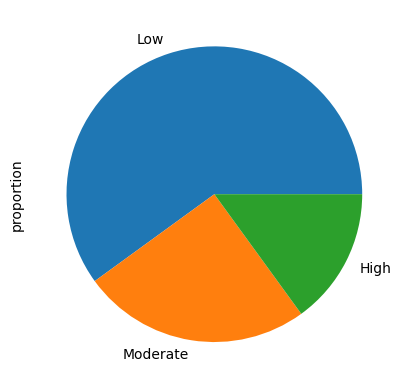

In [ ]:
df['diabetes_risk'].value_counts(normalize = True).plot(kind='pie')

Colunas
- idade
- genero
- cidade (pode ser relevante pela cultura de alimentação)
- bmi (indice de massa corporal)
- historia familiar de diabetes
- atividade física
- tipo de dieta (vegana, vegetaria, só peixes, não vegetariana)
- status de fumante
- nivel de consumo de alcool
- horas por noite
- nivel de stress
- insulina
- hba1c
- pressao sanguinia
- outro tipo de pressao sanguinia
- cm cintura
- faixa de renda

In [ ]:
df['diet_type'].value_counts()

,count
diet_type,
Non-Vegetarian,8195
Vegetarian,6074
Pescatarian,445
Vegan,286


In [ ]:
df.head()

,patient_id,age,gender,city,bmi,family_history_diabetes,physical_activity_level,diet_type,smoking_status,alcohol_consumption,hours_sleep_per_night,stress_level,fasting_blood_sugar,hba1c_level,blood_pressure_systolic,blood_pressure_diastolic,waist_circumference_cm,income_bracket,diabetes_risk
0,1,47,Female,Mumbai,26.5,Yes,Sedentary,Vegetarian,Never,Never,9.0,8,178,7.3,146,90,107.1,High,Low
1,2,53,Female,Mumbai,20.5,Yes,Moderate,Vegetarian,Never,Never,7.0,6,152,6.9,156,100,93.8,Low,Low
2,3,47,Male,Thane,31.3,No,Moderate,Non-Vegetarian,Current,Regular,7.0,7,168,6.6,150,102,113.5,Low,High
3,4,41,Male,Bengaluru,22.8,No,Sedentary,Non-Vegetarian,Never,Never,9.0,5,155,6.7,126,92,109.6,Middle,Low
4,5,57,Female,Bengaluru,16.7,No,Sedentary,Non-Vegetarian,Current,Occasional,6.5,10,188,6.7,130,90,80.8,High,Low


In [ ]:
df.tail()

,patient_id,age,gender,city,bmi,family_history_diabetes,physical_activity_level,diet_type,smoking_status,alcohol_consumption,hours_sleep_per_night,stress_level,fasting_blood_sugar,hba1c_level,blood_pressure_systolic,blood_pressure_diastolic,waist_circumference_cm,income_bracket,diabetes_risk
14995,14996,47,Male,Mumbai,37.7,No,Sedentary,Non-Vegetarian,Never,Never,6.8,7,213,8.1,150,100,141.7,High,High
14996,14997,48,Female,Mumbai,20.6,No,Moderate,Non-Vegetarian,Never,NaN,6.0,8,162,6.5,132,80,91.0,NaN,Low
14997,14998,34,Female,Nagpur,17.9,No,Active,Vegetarian,Never,Never,7.0,6,137,6.5,136,90,88.8,Low,Low
14998,14999,56,Male,Ahmedabad,20.7,Yes,Active,Vegetarian,Never,Never,6.0,5,163,6.9,140,87,94.8,Low,Low
14999,15000,54,Male,Surat,34.5,No,Moderate,Vegetarian,Never,Never,7.4,2,186,7.2,150,88,130.4,Middle,Moderate


Fiz uma analise mais supercial nos dados, agora quero entender as partes mais estatísticas como:
- distribuições (quartis, desvio padrão, media e mediana)
- correlações (person para correlações lineares e spearmen para correlação monotonicas)
- nova correlação (kendall)

| Correlação   | O que mede                  | Tipo de relação    | Sensibilidade a outliers |
| ------------ | --------------------------- | ------------------ | ------------------------ |
| **Pearson**  | Associação linear           | Linear             | Alta                     |
| **Spearman** | Associação monotônica       | Monotônica         | Menor                    |
| **Kendall**  | Concordância entre rankings | Monotônica/ordinal | Baixa                    |


## 2. Pré-Processamento
- Preenchimento de Valores Nulos
- Converter string para INT
- Ordinal Encoder da Variavel Resposta
- Correlações

In [ ]:
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.compose import make_column_transformer

from sklearn.model_selection import train_test_split

Preenchendo Valores Nulos

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 19 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   patient_id                15000 non-null  int64  
 1   age                       15000 non-null  int64  
 2   gender                    15000 non-null  object 
 3   city                      15000 non-null  object 
 4   bmi                       15000 non-null  float64
 5   family_history_diabetes   15000 non-null  object 
 6   physical_activity_level   15000 non-null  object 
 7   diet_type                 15000 non-null  object 
 8   smoking_status            14528 non-null  object 
 9   alcohol_consumption       11212 non-null  object 
 10  hours_sleep_per_night     15000 non-null  float64
 11  stress_level              15000 non-null  int64  
 12  fasting_blood_sugar       15000 non-null  int64  
 13  hba1c_level               15000 non-null  float64
 14  blood_

In [ ]:
df['smoking_status'].value_counts()

,count
smoking_status,
Never,10119
Current,2946
Former,1463


In [ ]:
df['smoking_status'].value_counts()

,count
smoking_status,
Never,10119
Current,2946
Former,1463


In [ ]:
df['alcohol_consumption'].value_counts()

,count
alcohol_consumption,
Never,5616
Occasional,4483
Regular,1113


In [ ]:
df['income_bracket'].value_counts()

,count
income_bracket,
Middle,7305
High,3844
Low,3388


In [ ]:
# como sao variaveis categoricas, vou preencher os NA com a moda (categoria mais frequente)
df['alcohol_consumption'].fillna('Never', inplace= True)
df['income_bracket'].fillna('Middle', inplace= True)
df['smoking_status'].fillna('Never', inplace = True)

/tmp/ipykernel_6272/673642991.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['alcohol_consumption'].fillna('Never', inplace= True)
/tmp/ipykernel_6272/673642991.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)'

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 19 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   patient_id                15000 non-null  int64  
 1   age                       15000 non-null  int64  
 2   gender                    15000 non-null  object 
 3   city                      15000 non-null  object 
 4   bmi                       15000 non-null  float64
 5   family_history_diabetes   15000 non-null  object 
 6   physical_activity_level   15000 non-null  object 
 7   diet_type                 15000 non-null  object 
 8   smoking_status            15000 non-null  object 
 9   alcohol_consumption       15000 non-null  object 
 10  hours_sleep_per_night     15000 non-null  float64
 11  stress_level              15000 non-null  int64  
 12  fasting_blood_sugar       15000 non-null  int64  
 13  hba1c_level               15000 non-null  float64
 14  blood_

In [ ]:
# antes de fazer o hot enconder, quero entender quantas colunas ele vai gerar baseado no meu dataset
for i in df.columns:
  if df[i].nunique() > 3 and df[i].dtype == 'object':
    print(i, df[i].nunique())

city 18
diet_type 4


vou aceitar + 17 colunas da cidade da pessoa

OrdinalEncoder

In [ ]:
df['diabetes_risk'].value_counts()

,count
diabetes_risk,
Low,9000
Moderate,3750
High,2250


In [ ]:
ordinal = OrdinalEncoder(
    categories=[['Low', 'Moderate', 'High']]
)

df['diabetes_risk'] = ordinal.fit_transform(df[['diabetes_risk']])

In [ ]:
df['diabetes_risk'].value_counts()

,count
diabetes_risk,
0.0,9000
1.0,3750
2.0,2250


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 19 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   patient_id                15000 non-null  int64  
 1   age                       15000 non-null  int64  
 2   gender                    15000 non-null  object 
 3   city                      15000 non-null  object 
 4   bmi                       15000 non-null  float64
 5   family_history_diabetes   15000 non-null  object 
 6   physical_activity_level   15000 non-null  object 
 7   diet_type                 15000 non-null  object 
 8   smoking_status            15000 non-null  object 
 9   alcohol_consumption       15000 non-null  object 
 10  hours_sleep_per_night     15000 non-null  float64
 11  stress_level              15000 non-null  int64  
 12  fasting_blood_sugar       15000 non-null  int64  
 13  hba1c_level               15000 non-null  float64
 14  blood_

#### Correlações (Pearson, Spearman, Kendall)

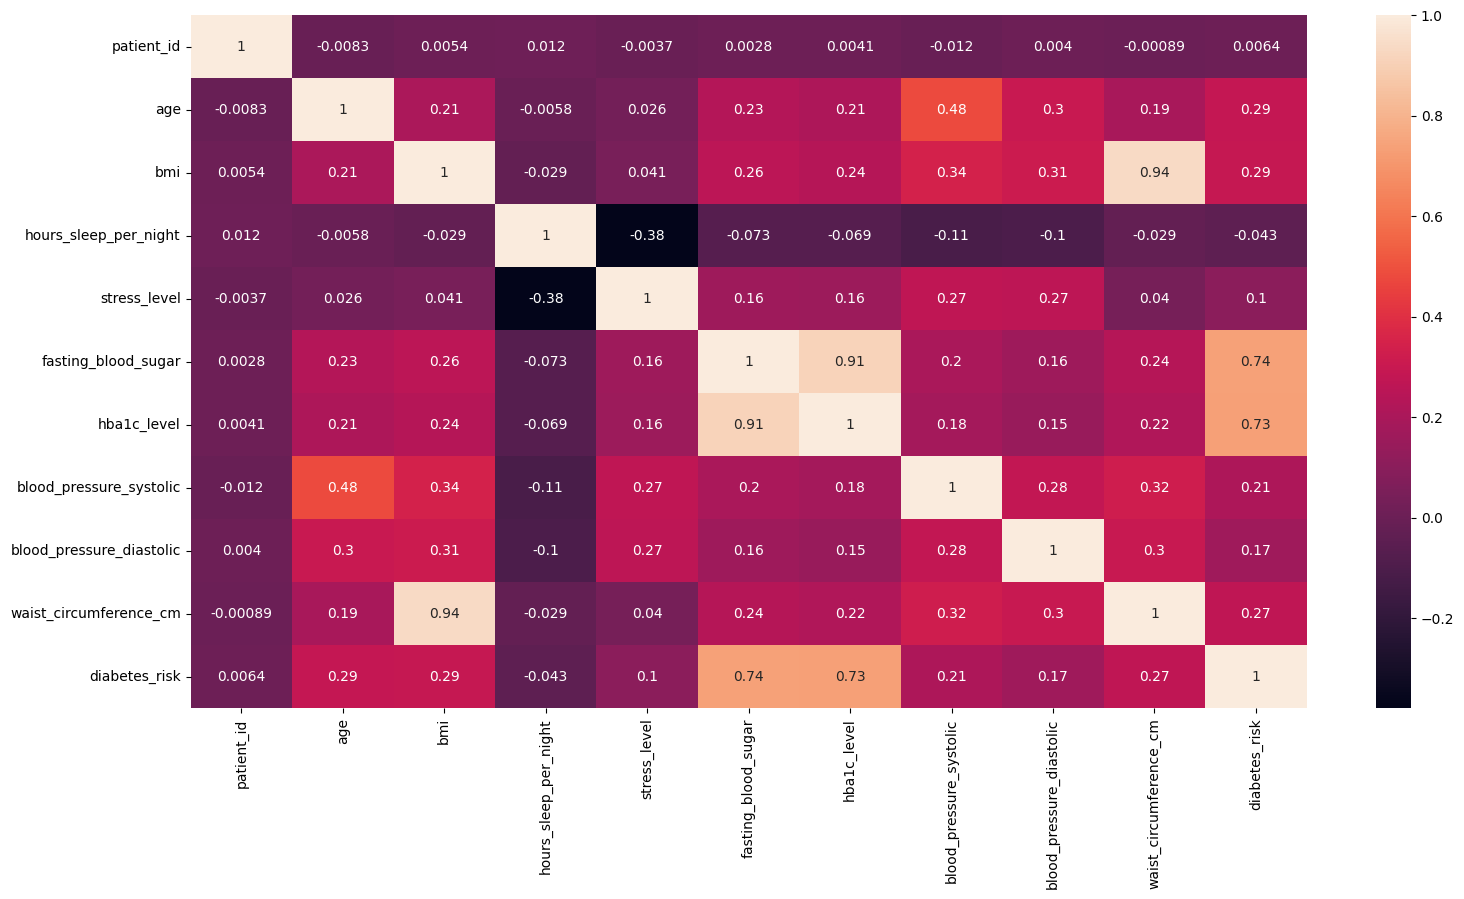

In [ ]:
plt.rcParams['figure.figsize'] = (18,9)

df_numerico = df.select_dtypes(include=['number'])

matriz_correlacao_pearson = sns.heatmap(df_numerico.corr(), annot=True)

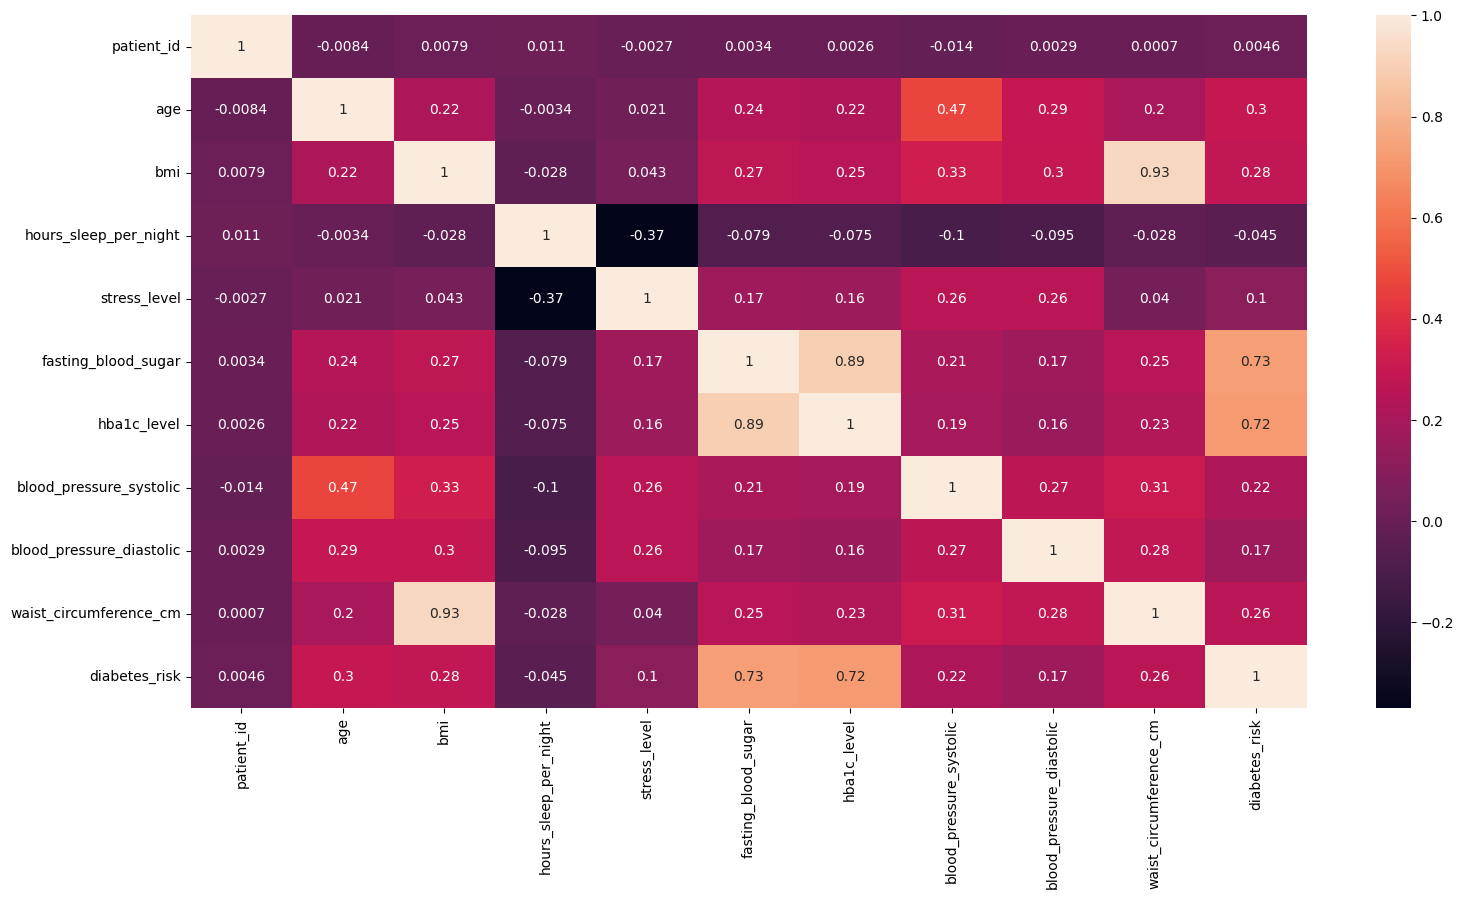

In [ ]:
plt.rcParams['figure.figsize'] = (18,9)

df_numerico = df.select_dtypes(include=['number'])

matriz_correlacao_pearson = sns.heatmap(df_numerico.corr(method='spearman'), annot=True)

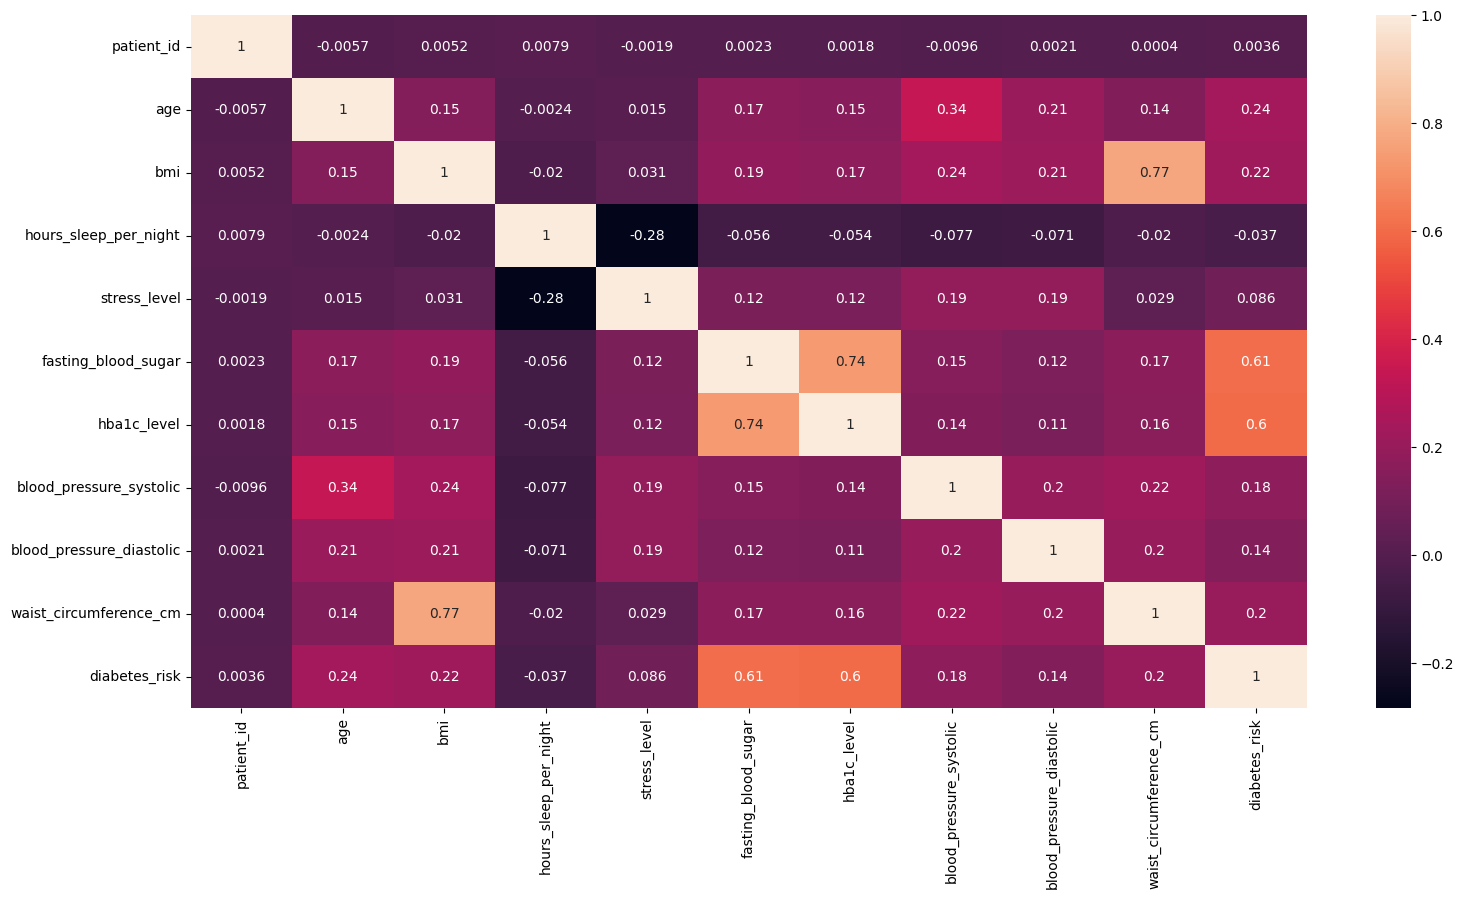

In [ ]:
plt.rcParams['figure.figsize'] = (18,9)

df_numerico = df.select_dtypes(include=['number'])

matriz_correlacao_pearson = sns.heatmap(df_numerico.corr(method='kendall'), annot=True)

#### OneHotEncoder

In [ ]:
X = df.drop('diabetes_risk', axis= 1)
y = df['diabetes_risk']

In [ ]:
colunas_str = X.select_dtypes(include='object')
colunas_str = list(colunas_str)

one_hot = make_column_transformer(
    (OneHotEncoder(drop='if_binary'), colunas_str),
    remainder = 'passthrough',
    sparse_threshold=0
)

In [ ]:
x_columns = X.columns
X = one_hot.fit_transform(X)
X = pd.DataFrame(X, columns = one_hot.get_feature_names_out())

In [ ]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 48 columns):
 #   Column                                            Non-Null Count  Dtype  
---  ------                                            --------------  -----  
 0   onehotencoder__gender_Female                      15000 non-null  float64
 1   onehotencoder__gender_Male                        15000 non-null  float64
 2   onehotencoder__gender_Other                       15000 non-null  float64
 3   onehotencoder__city_Ahmedabad                     15000 non-null  float64
 4   onehotencoder__city_Bengaluru                     15000 non-null  float64
 5   onehotencoder__city_Bhopal                        15000 non-null  float64
 6   onehotencoder__city_Chennai                       15000 non-null  float64
 7   onehotencoder__city_Delhi                         15000 non-null  float64
 8   onehotencoder__city_Hyderabad                     15000 non-null  float64
 9   onehotencoder__ci

In [ ]:
X.drop(columns=['remainder__patient_id'], inplace = True)

#### Train_Test_Split

In [ ]:
X_treino, X_test, y_treino, y_test = train_test_split(X, y , stratify=y, test_size = 0.30)

In [ ]:
y.value_counts(normalize= True)

,proportion
diabetes_risk,
0.0,0.60
1.0,0.25
2.0,0.15


In [ ]:
y_treino.value_counts(normalize= True)

,proportion
diabetes_risk,
0.0,0.60
1.0,0.25
2.0,0.15


In [ ]:
y_test.value_counts(normalize= True)

,proportion
diabetes_risk,
0.0,0.60
1.0,0.25
2.0,0.15


In [ ]:
X_treino.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10500 entries, 13656 to 9760
Data columns (total 47 columns):
 #   Column                                            Non-Null Count  Dtype  
---  ------                                            --------------  -----  
 0   onehotencoder__gender_Female                      10500 non-null  float64
 1   onehotencoder__gender_Male                        10500 non-null  float64
 2   onehotencoder__gender_Other                       10500 non-null  float64
 3   onehotencoder__city_Ahmedabad                     10500 non-null  float64
 4   onehotencoder__city_Bengaluru                     10500 non-null  float64
 5   onehotencoder__city_Bhopal                        10500 non-null  float64
 6   onehotencoder__city_Chennai                       10500 non-null  float64
 7   onehotencoder__city_Delhi                         10500 non-null  float64
 8   onehotencoder__city_Hyderabad                     10500 non-null  float64
 9   onehotencoder__city

Vou fazer um scaler de ultima hora

In [ ]:
from sklearn.preprocessing import StandardScaler

In [ ]:
scaler = StandardScaler()

X_treino_normalizado = scaler.fit_transform(X_treino)
X_treino_normalizado = pd.DataFrame(X_treino_normalizado)

X_test_normalizado = scaler.transform(X_test) #aqui no teste somente transform para nao ocorrer datalakage

O scaler aprende:

média de cada variável;
desvio padrão de cada variável.

Você não deve fazer:

`scaler.fit_transform(X_test)`

porque estaria deixando o conjunto de teste influenciar o processo de modelagem (data leakage).

## 3. Modelagem

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier

Na LogisticRegression, ele define como o modelo trata um problema com mais de duas classes.

O modelo considera todas as classes simultaneamente (calculando a probabilidade de cada classe sobre 100%, e escolhe a qual a probabilidade mais alta).

multi_class="ovr"

Significa One-vs-Rest (OvR).

Em vez de um único problema com 3 classes, ele cria vários classificadores binários:

Nas versões atuais do scikit-learn, multi_class na LogisticRegression está deprecated e a tendência é usar o comportamento multinomial diretamente para os solvers que o suportam. Então, em código novo, não vale decorar multi_class="multinomial" como se fosse obrigatório.

In [ ]:
arvore_decisao = DecisionTreeClassifier(max_depth = 3)
regressao_logistica = LogisticRegression(multi_class='multinomial')
random_forest = RandomForestClassifier(max_depth = 3, n_estimators=100)
#n_estimators = quantidade de arvores na floresta; min_samples_split = define o numero de amostras necessarias para dividir um nó
#min_samples_leaf = é o numero minimo de amostras que uma folha pode ter; bootstrap = define se cada arvore recebe uma amostra bootstrap
#n_jobs = numero de processadores que podem ser utilizados; class_weight = da mais peso as classes minoritarias;

In [ ]:
arvore_decisao.fit(X_treino_normalizado, y_treino)
regressao_logistica.fit(X_treino_normalizado, y_treino)
random_forest.fit(X_treino_normalizado, y_treino)

/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


RandomForestClassifier(max_depth=3)

In [ ]:
modelos = [arvore_decisao, regressao_logistica, random_forest]

for modelo in modelos:
  print(modelo, f'\nscore de treino: {modelo.score(X_treino_normalizado, y_treino)}\n')

DecisionTreeClassifier(max_depth=3) 
score de treino: 0.7557142857142857

LogisticRegression(multi_class='multinomial') 
score de treino: 0.7986666666666666

RandomForestClassifier(max_depth=3) 
score de treino: 0.7159047619047619



## 4. Analise das Métricas

In [ ]:
from sklearn.metrics import classification_report, RocCurveDisplay

In [ ]:
y_previstos = [modelo.predict(X_test_normalizado) for modelo in modelos]

In [ ]:
relatorios = [
    classification_report(y_test, y_previsto)
    for y_previsto in y_previstos
]
len(relatorios)

3

In [ ]:
print(modelos)

[DecisionTreeClassifier(max_depth=3), LogisticRegression(multi_class='multinomial'), RandomForestClassifier(max_depth=3)]


In [ ]:
print(modelos[0])
print(relatorios[0])

DecisionTreeClassifier(max_depth=3)
              precision    recall  f1-score   support

         0.0       0.85      0.86      0.86      2700
         1.0       0.52      0.57      0.55      1125
         2.0       0.81      0.63      0.71       675

    accuracy                           0.76      4500
   macro avg       0.73      0.69      0.70      4500
weighted avg       0.76      0.76      0.76      4500



In [ ]:
print(modelos[1])
print(relatorios[1])

LogisticRegression(multi_class='multinomial')
              precision    recall  f1-score   support

         0.0       0.85      0.91      0.88      2700
         1.0       0.60      0.54      0.57      1125
         2.0       0.81      0.74      0.78       675

    accuracy                           0.79      4500
   macro avg       0.75      0.73      0.74      4500
weighted avg       0.78      0.79      0.78      4500



In [ ]:
print(modelos[2])
print(relatorios[2])

RandomForestClassifier(max_depth=3)
              precision    recall  f1-score   support

         0.0       0.72      0.98      0.83      2700
         1.0       0.53      0.23      0.32      1125
         2.0       0.89      0.45      0.60       675

    accuracy                           0.71      4500
   macro avg       0.71      0.55      0.58      4500
weighted avg       0.70      0.71      0.67      4500



Modelo mais performatíco: Regressão Logística